# 09 · CATE — *who* responds (heterogeneous effects)

**NB 09.** The ATE answers "does it work *on average*?" The **CATE** answers "for *whom*?" —
$$\tau(x)=\mathbb E\big[Y(1)-Y(0)\mid X=x\big].$$
This is the gateway to **targeting**: don't treat everyone, treat those who benefit. We build the
estimator family **S- / T- / X-learner → causal forest** (Künzel 2019; Wager–Athey 2018; Nie–Wager),
and — because we *author* the DGP — we **validate $\hat\tau(x)$ against the known surface $\tau(x)$**:
RMSE, calibration, and the honest-forest **CI coverage of the true $\tau(x)$**. That last one is Lyra's
superpower applied to heterogeneity — a real platform can never check it. (Turning $\hat\tau$ into a
*policy* — Qini/RATE/uplift — is **NB 10**; here we estimate, and tease the ranking.)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor as GBR
from econml.dml import CausalForestDML
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY

## 1. A world with heterogeneous effects (known $\tau(x)$)

A randomized experiment ($e=\Pr(T{=}1)=0.5$) on $d=5$ covariates (three are noise). The outcome is a
**nonlinear nuisance** $m(x)$ plus the treatment term, centered so the per-$x$ contrast is exactly
$\tau(x)$:
$$Y = \underbrace{m(x)}_{\text{baseline}} + (T-e)\,\tau(x) + \varepsilon,\qquad
  \tau(x)=0.5 + x_0 - 0.5\,x_1,\quad m(x)=\sin 2x_0 + x_1^2 + 0.5\,x_2.$$
The effect is **+0.5 on average but ranges widely** — some users are strongly helped, some hurt.

ATE = E[τ(X)] = +0.505   but τ(x) ranges -4.15 … +4.86


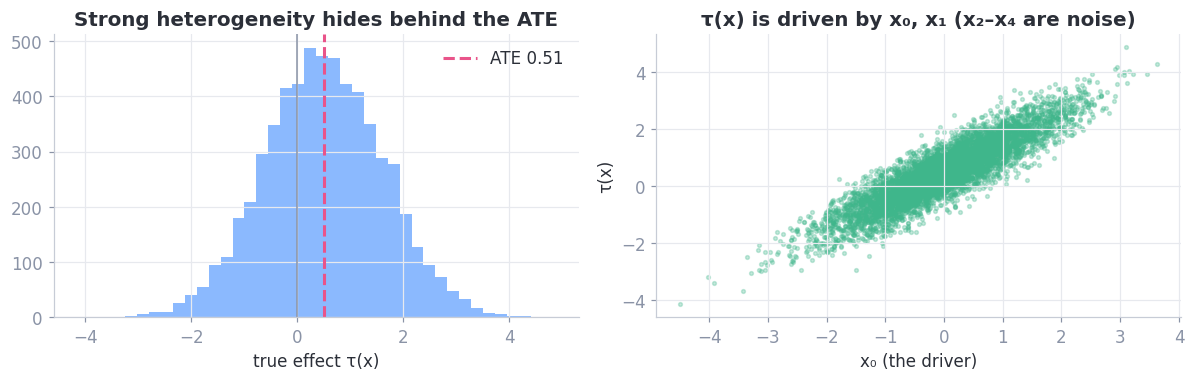

In [2]:
def simulate_hte(n=6000, d=5, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, d))
    tau = 0.5 + X[:, 0] - 0.5 * X[:, 1]                       # the true CATE surface (we author it)
    m = np.sin(2 * X[:, 0]) + X[:, 1] ** 2 + 0.5 * X[:, 2]    # nonlinear nuisance
    T = rng.integers(0, 2, n)
    y = m + (T - 0.5) * tau + rng.standard_normal(n)
    cols = {f"x{j}": X[:, j] for j in range(d)}
    return pd.DataFrame({**cols, "treat": T, "y": y, "tau": tau}), X, T, y, tau

df, X, T, y, tau = simulate_hte()
print(f"ATE = E[τ(X)] = {tau.mean():+.3f}   but τ(x) ranges {tau.min():+.2f} … {tau.max():+.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(tau, bins=40, color=BLUE, alpha=0.8); ax[0].axvline(tau.mean(), color=PINK, ls="--", lw=2, label=f"ATE {tau.mean():.2f}")
ax[0].axvline(0, color=GRAY, lw=1); ax[0].set_xlabel("true effect τ(x)"); ax[0].set_title("Strong heterogeneity hides behind the ATE"); ax[0].legend()
ax[1].scatter(X[:, 0], tau, s=6, alpha=0.3, color=GREEN); ax[1].set_xlabel("x₀ (the driver)"); ax[1].set_ylabel("τ(x)")
ax[1].set_title("τ(x) is driven by x₀, x₁ (x₂–x₄ are noise)"); plt.tight_layout(); plt.show()

An A/B test here reports "+0.5, ship" — true, but it **misses that a third of users are harmed**.
To target, we need $\tau(x)$, not its average.

## 2. Meta-learners — S, T, X

Build $\tau(x)$ out of standard regressions (Künzel et al. 2019):
- **S-learner**: one model on $[X,T]$; $\hat\tau(x)=\hat\mu(x,1)-\hat\mu(x,0)$. Simple, but regularization
  shrinks $\tau$ toward 0 (treatment is "just another feature").
- **T-learner**: separate $\hat\mu_1,\hat\mu_0$ per arm; $\hat\tau=\hat\mu_1-\hat\mu_0$. Splits the data
  (variance) and each model fits the *nuisance* $m(x)$, not the effect.
- **X-learner**: impute individual effects, then regress them on $x$ — best when the response surface is
  complex or arms are unbalanced.

In [3]:
def s_learner(X, T, y, base=GBR):
    mu = base().fit(np.c_[X, T], y)
    return lambda Z: mu.predict(np.c_[Z, np.ones(len(Z))]) - mu.predict(np.c_[Z, np.zeros(len(Z))])

def t_learner(X, T, y, base=GBR):
    m1 = base().fit(X[T == 1], y[T == 1]); m0 = base().fit(X[T == 0], y[T == 0])
    return lambda Z: m1.predict(Z) - m0.predict(Z)

def x_learner(X, T, y, e=0.5, base=GBR):
    m1 = base().fit(X[T == 1], y[T == 1]); m0 = base().fit(X[T == 0], y[T == 0])
    d1 = y[T == 1] - m0.predict(X[T == 1])               # treated: actual − imputed control
    d0 = m1.predict(X[T == 0]) - y[T == 0]               # control: imputed treated − actual
    t1 = base().fit(X[T == 1], d1); t0 = base().fit(X[T == 0], d0)
    return lambda Z: e * t0.predict(Z) + (1 - e) * t1.predict(Z)

# fit on a train split, validate τ̂(x) vs the true τ(x) on a held-out split
dtr, Xtr, Ttr, ytr, _ = simulate_hte(n=6000, seed=1)
dte, Xte, Tte, yte, tau_te = simulate_hte(n=4000, seed=2)
learners = {"S-learner": s_learner, "T-learner": t_learner, "X-learner": x_learner}
preds = {name: fn(Xtr, Ttr, ytr)(Xte) for name, fn in learners.items()}
rmse = lambda a: float(np.sqrt(np.mean((a - tau_te) ** 2)))
for name in learners:
    print(f"  {name:<10} RMSE(τ̂, τ) = {rmse(preds[name]):.3f}")

  S-learner  RMSE(τ̂, τ) = 0.334
  T-learner  RMSE(τ̂, τ) = 0.339
  X-learner  RMSE(τ̂, τ) = 0.211


## 3. The causal forest — honest CIs for $\tau(x)$

A **causal forest** (Wager–Athey 2018; the GRF family) grows *honest* trees that split to maximize effect
heterogeneity and yields **valid pointwise confidence intervals** — asymptotically normal $\hat\tau(x)$.
We use econml's `CausalForestDML` (residualizes $Y,T$ on $X$ first — Robinson/R-learner style — so it's
robust to the nuisance $m(x)$).

In [4]:
cf = CausalForestDML(model_y=GBR(), model_t=GBR(), discrete_treatment=True,
                     n_estimators=400, random_state=0).fit(ytr, Ttr, X=Xtr)
tau_cf = cf.effect(Xte)
lb, ub = cf.effect_interval(Xte, alpha=0.05)
preds["causal forest"] = tau_cf
cover = float(np.mean((lb <= tau_te) & (tau_te <= ub)))
print(f"  causal forest RMSE(τ̂, τ) = {rmse(tau_cf):.3f}")
print(f"  causal-forest 95% CI coverage of the TRUE τ(x) = {cover:.2f}   ← a real platform can't check this")

  causal forest RMSE(τ̂, τ) = 0.256
  causal-forest 95% CI coverage of the TRUE τ(x) = 0.88   ← a real platform can't check this


## 4. Which wins — validate against the known surface

We can score every learner **against ground truth** (RMSE) and *see* the calibration — $\hat\tau$ vs
$\tau$ should lie on the diagonal.

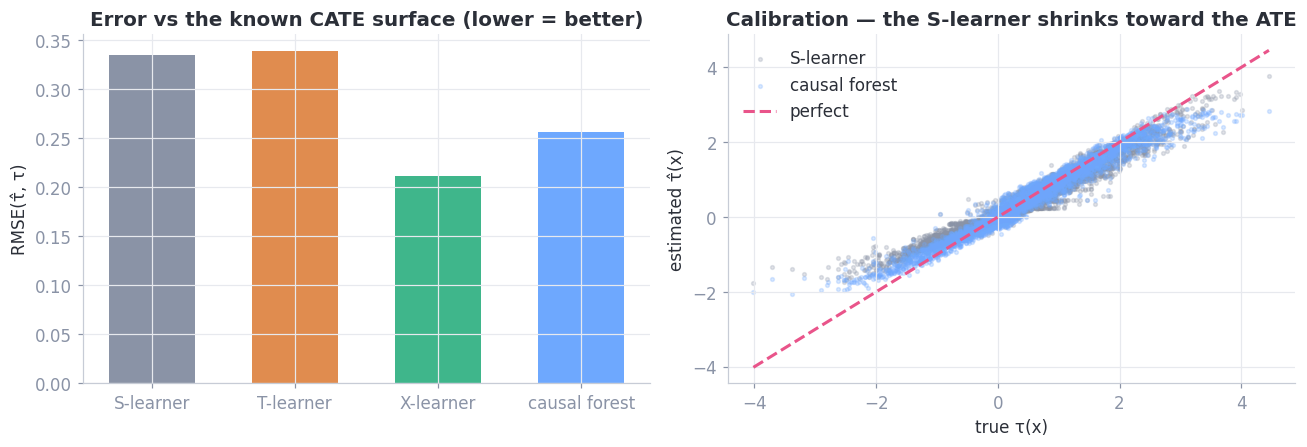

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
order = ["S-learner", "T-learner", "X-learner", "causal forest"]
cols = [GRAY, ORANGE, GREEN, BLUE]
ax[0].bar(order, [rmse(preds[k]) for k in order], color=cols, width=.6)
ax[0].set_ylabel("RMSE(τ̂, τ)"); ax[0].set_title("Error vs the known CATE surface (lower = better)")
for k, c in zip(["S-learner", "causal forest"], [GRAY, BLUE]):
    ax[1].scatter(tau_te, preds[k], s=6, alpha=0.25, color=c, label=k)
lim = [tau_te.min(), tau_te.max()]; ax[1].plot(lim, lim, color=PINK, ls="--", lw=2, label="perfect")
ax[1].set_xlabel("true τ(x)"); ax[1].set_ylabel("estimated τ̂(x)"); ax[1].set_title("Calibration — the S-learner shrinks toward the ATE"); ax[1].legend()
plt.tight_layout(); plt.show()

The S-learner's cloud is **flattened toward the ATE** (regularization bias); the X-learner and forest
track the diagonal closely (lowest RMSE here goes to the X-learner). The forest's distinguishing edge is
**honest pointwise CIs** that cover the true $\tau(x)$ at ~90% — heterogeneity we can *trust*, not just
point at.

## 5. The targeting teaser (→ NB 10)

Rank users by $\hat\tau(x)$ and you have a **treatment priority list**. As a preview: among the top-decile
by the forest's $\hat\tau$, the *true* average effect is far above the ATE — real value a null-looking A/B
would leave on the table. NB 10 turns this into a calibrated **policy** (Qini / RATE / value).

In [6]:
top = np.argsort(-tau_cf)[: len(tau_cf) // 10]
print(f"ATE (treat everyone)                       : {tau_te.mean():+.3f}")
print(f"true effect among the top-decile by τ̂(x)   : {tau_te[top].mean():+.3f}   ({tau_te[top].mean()/tau_te.mean():.1f}× the ATE)")

ATE (treat everyone)                       : +0.519
true effect among the top-decile by τ̂(x)   : +2.459   (4.7× the ATE)


## 6. Promote → `lyra/cate.py` + `lyra/dgp`

The learners become `lyra/cate.py` (`SLearner`, `TLearner`, `XLearner`, `CausalForest` — a `fit(df)` /
`predict_cate(X)` family) and the world becomes `HeteroDGP` (`lyra/dgp`, exposing the true `tau(X)`).
`tests/test_cate.py` asserts the X-learner/forest recover $\tau(x)$ and the forest's CI covers it. **Next
(`ROADMAP.md`): NB 10 — uplift evaluation & policy** (Qini/AUUC/RATE · policy learning · OPE).

In [7]:
from lyra.dgp import HeteroDGP
from lyra.cate import XLearner, CausalForest

H = HeteroDGP(seed=1)
tr = H.sample(6000, seed=1); te = H.sample(4000, seed=2)
true_te = HeteroDGP(seed=1).tau(te[[f"x{j}" for j in range(5)]].to_numpy())
xl = XLearner().fit(tr); cf2 = CausalForest().fit(tr)
Xte2 = te[[f"x{j}" for j in range(5)]].to_numpy()
print(f"promoted XLearner   RMSE = {np.sqrt(np.mean((xl.predict_cate(Xte2) - true_te) ** 2)):.3f}")
print(f"promoted CausalForest RMSE = {np.sqrt(np.mean((cf2.predict_cate(Xte2) - true_te) ** 2)):.3f}, "
      f"ATE = {cf2.predict_cate(Xte2).mean():+.3f} (truth {true_te.mean():+.3f})")

promoted XLearner   RMSE = 0.215
promoted CausalForest RMSE = 0.255, ATE = +0.506 (truth +0.519)
